In [2]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pymaster as nmt
from scipy import optimize
from scipy.linalg import det
import sys
sys.path.append('../')
from scripts.compute_covariance import compute_covariance
from scripts.mask_maps import mask_maps
input_path="/renoir/shoaib/SMICA_Paper/data"

In [3]:
nside=256
npix=hp.nside2npix(nside)
freqs=np.arange(544,1088,step=10) #MHz
nfreqs=len(freqs)-1
lmax=3*nside -1
ells=np.arange(2,lmax+1)
almsize=hp.Alm.getsize(lmax)
r=3 #foreground model rank
# n_bins=10
bin_width=10

In [4]:
## Helper functions

def apply_mask_with_nan(data, mask):
    """Apply mask to data, setting masked regions (mask==0) to NaN for better visualization."""
    masked_data = data * mask
    masked_data[mask == 0] = np.nan
    return masked_data

def rotate_maps(map: np.ndarray)-> np.ndarray:
    """Convert maps frequency by frequency from galactic coordinates to celestial/equatorial coordinates

    Args:
        map : map in pixels to be rotated
    """
    rot=hp.rotator.Rotator(coord=['G', 'C'])
    rotated=np.zeros_like(map)
    for i in range(nfreqs):
        print(f"Rotating map {i+1}")
        rotated[i]=rot.rotate_map_alms(map[i])
    return rotated

def bin_spectra(cl,nside, delta):
    b= nmt.NmtBin.from_lmax_linear(lmax, nlb=delta)
    nbins = b.get_n_bands()
    leff = b.get_effective_ells()
    cl_binned= np.zeros((nbins, nfreqs, nfreqs))

    for i in range(nfreqs):
        for j in range(nfreqs):
            cl_binned[:, i, j] = b.bin_cell(cl[:, i, j])
            
    return leff,nbins,cl_binned

def normalize_covariance_by_sky_fraction(mask, fgds_cl, hi_cl, noise_cl, sky_cl):
    """Normalize covariance matrices by the sky fraction.
    
    Parameters:
    -----------
    mask : np.ndarray
        Sky mask
    fgds_cl, hi_cl, noise_cl, sky_cl : np.ndarray
        Covariance matrices to normalize
    
    Returns:
    --------
    fsky : float
        Sky fraction
    pseudo_fgds_cl, pseudo_hi_cl, pseudo_noise_cl, pseudo_sky_cl : np.ndarray
        Normalized covariance matrices
    """
    fsky = mask.mean()
    pseudo_fgds_cl = fgds_cl / fsky
    pseudo_hi_cl = hi_cl / fsky
    pseudo_noise_cl = noise_cl / fsky
    pseudo_sky_cl = sky_cl / fsky
    
    return fsky, pseudo_fgds_cl, pseudo_hi_cl, pseudo_noise_cl, pseudo_sky_cl

## Mask
Create patch of sky near the south pole

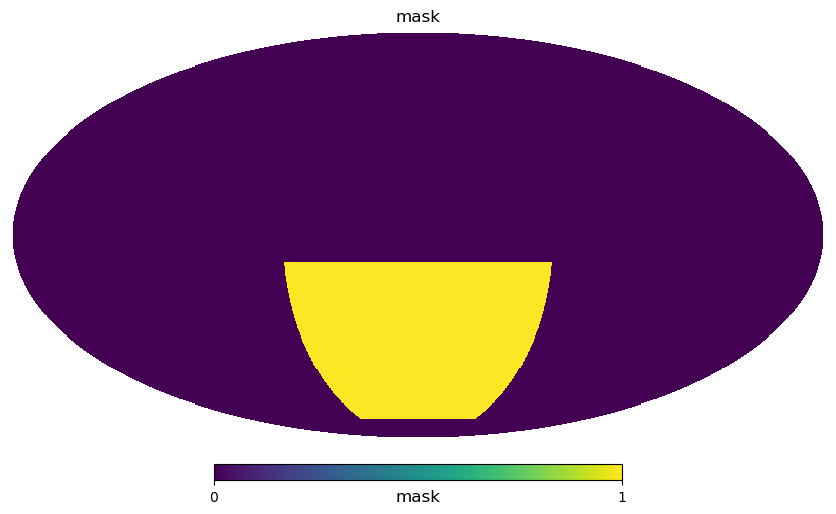

In [5]:
def create_sky_patch_mask(nside, ra_min, ra_max, dec_min, dec_max):
    """Create a rectangular sky patch mask in HEALPix format.
    
    Parameters:
    -----------
    nside : int
        HEALPix nside parameter
    ra_min, ra_max : float
        RA bounds in degrees
    dec_min, dec_max : float
        Declination bounds in degrees
    
    Returns:
    --------
    mask : np.ndarray
        Binary mask (1 inside region, 0 outside)
    """
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix), lonlat=False)
    ra = np.degrees(phi)
    dec = 90.0 - np.degrees(theta)
    
    # wrap RA to [-180, 180]
    ra = ((ra + 180) % 360) - 180
    
    # Build mask
    mask = (
        (ra >= ra_min) & (ra <= ra_max) &
        (dec >= dec_min) & (dec <= dec_max)
    ).astype(np.uint8)
    
    return mask

# Create mask with parameters
mask = create_sky_patch_mask(nside=256, ra_min=-60.0, ra_max=60.0, dec_min=-75.0, dec_max=-10.0)
hp.mollview(mask, title="mask", unit="mask")

In [6]:
ff=np.load(f"{input_path}/smoothed_ff_maps.npy")*1e-3 #mK
sync=np.load(f"{input_path}/smoothed_sync_maps.npy")*1e-3 #mK
noise=np.load(f"{input_path}/noise_maps.npy")[:-1] *1e3 #mK

In [7]:
hi_cl2=np.load(f"{input_path}/cal_hi_cov_mK.npy")
cl_hi = np.transpose(hi_cl2, (2, 0, 1))
hi_maps= np.load(f"{input_path}/hi_maps_mK.npy")

In [8]:
hi_cl2=np.load(f"{input_path}/cal_hi_cov_mK.npy")
cl_hi = np.transpose(hi_cl2, (2, 0, 1))
hi_maps= np.load(f"{input_path}/hi_maps_mK.npy")

ff=np.load(f"{input_path}/smoothed_ff_maps.npy")*1e-3 #mK
sync=np.load(f"{input_path}/smoothed_sync_maps.npy")*1e-3 #mK
noise=np.load(f"{input_path}/noise_maps.npy")[:-1] *1e3 #mK

fgds=(ff+sync)
# cl_hi=compute_covariance(hi_maps, lmax, almsize, nfreqs)
# cl_noise= compute_covariance(noise_maps, lmax, almsize, nfreqs)
# cl_fgds= compute_covariance(fgds, lmax, almsize, nfreqs)

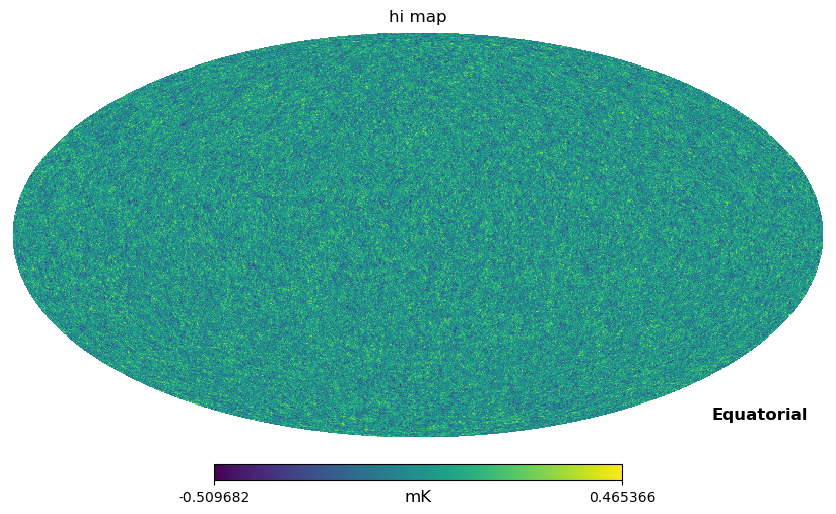

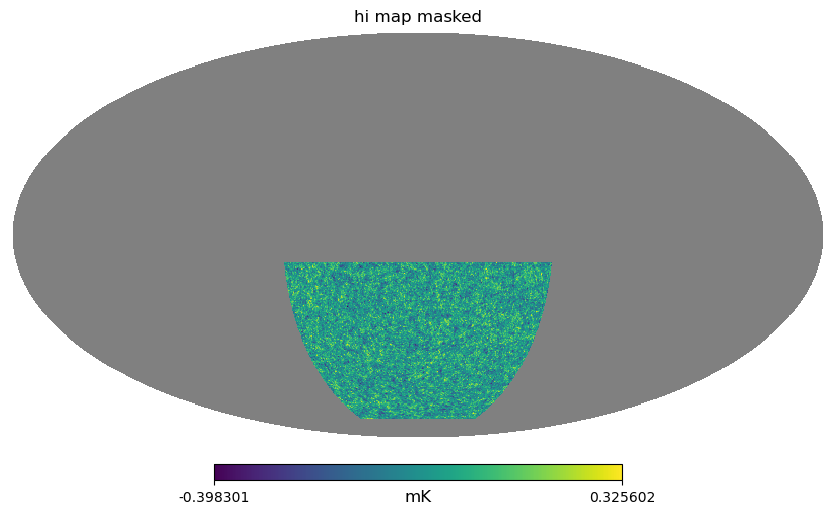

In [9]:
hp.mollview(hi_maps[0], coord=['G', 'C'], title="hi map", unit="mK")
rot=hp.rotator.Rotator(coord=['G', 'C'])
rotated_h=rot.rotate_map_pixel(hi_maps[0])

hp.mollview(apply_mask_with_nan(rotated_h, mask), unit="mK", title="hi map masked")

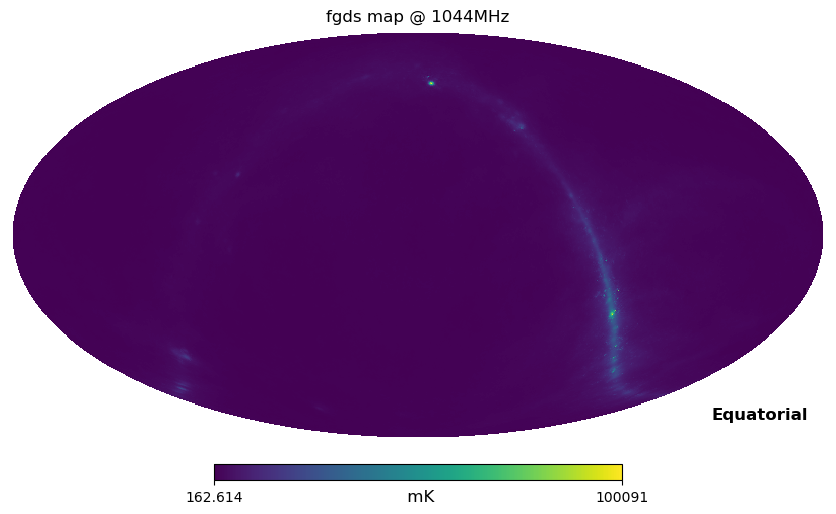

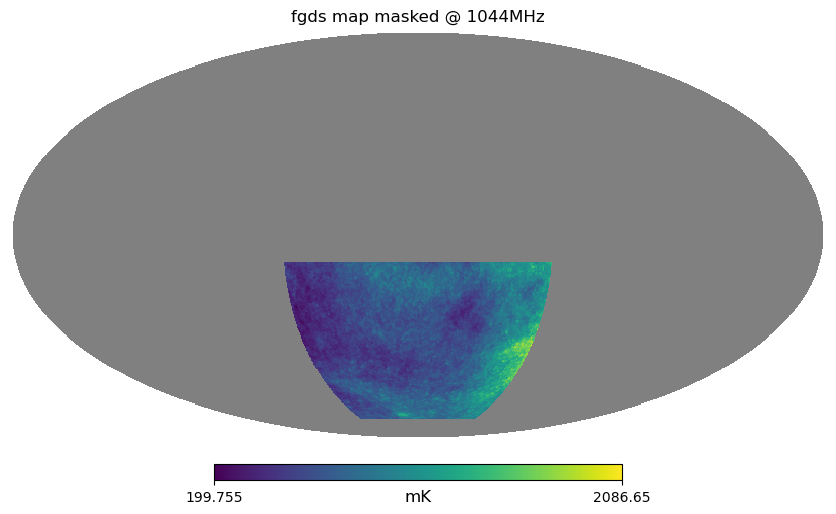

In [10]:
hp.mollview(sync[50]+ff[50], coord=['G', 'C'], title=f"fgds map @ {freqs[50]}MHz", unit=" mK")
# rot_s=hp.rotator.Rotator(coord=['G', 'C'])
rotated_a=rot.rotate_map_pixel((sync[50] +ff[50]))

hp.mollview(apply_mask_with_nan(rotated_a, mask), unit='mK', title=f"fgds map masked @ {freqs[50]}MHz")

In [11]:
fgds=(ff+sync) #mK
signal= fgds + hi_maps[:-1] +noise

## Rotate Maps

In [12]:
rotated_fgds=np.load(f"{input_path}/rotated_fgds.npy")
rotated_hi=np.load(f"{input_path}/rotated_hi.npy")
rotated_noise=np.load(f"{input_path}/rotated_noise.npy")
rotated_sky=np.load(f"{input_path}/rotated_sky.npy")

instead of rotating HI in pixel space rotate with alms because in pixel spaces it uses interpolation, since in rotating the rotated pixel falls in between pixels.

## Mask maps

In [13]:
fgds_masked,_= mask_maps(rotated_fgds, mask,almsize, lmax, nfreqs,  npix)
hi_masked,_= mask_maps(rotated_hi, mask,almsize, lmax, nfreqs,  npix)
noise_masked,_= mask_maps(rotated_noise, mask,almsize, lmax, nfreqs,  npix)
sky_masked,_= mask_maps(rotated_sky, mask,almsize, lmax, nfreqs,  npix)

In [14]:
fgds_cl= compute_covariance(fgds_masked, lmax,almsize, nfreqs)
hi_cl= compute_covariance(hi_masked, lmax,almsize, nfreqs)

In [15]:
noise_cl= compute_covariance(noise_masked, lmax,almsize, nfreqs)
sky_cl= compute_covariance(sky_masked, lmax,almsize, nfreqs)

In [16]:
# Apply normalization
fsky, pseudo_fgds_cl, pseudo_hi_cl, pseudo_noise_cl, pseudo_sky_cl = normalize_covariance_by_sky_fraction(
    mask, fgds_cl, hi_cl, noise_cl, sky_cl
)

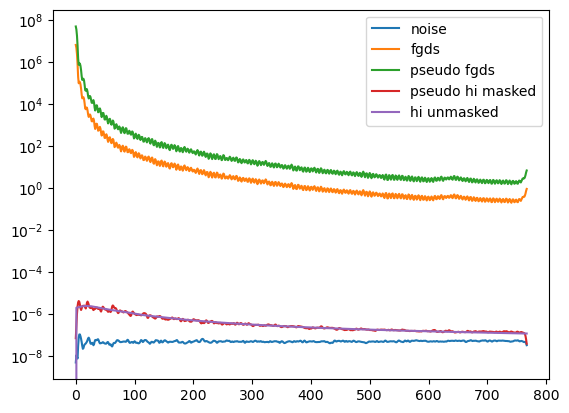

In [17]:
# plt.plot(sky_cl[:,0,0], label='sky')   
plt.plot(noise_cl[:,0,0], label='noise')
plt.plot(fgds_cl[:,0,0], label='fgds')
plt.plot(pseudo_fgds_cl[:,0,0], label='pseudo fgds')
plt.plot(pseudo_hi_cl[:,0,0], label='pseudo hi masked')
plt.plot(cl_hi[:,0,0], label='hi unmasked')


plt.legend()
plt.yscale('log')
# plt.loglog()

In [18]:
leff,n_bins, fgds_binned= bin_spectra(pseudo_fgds_cl, nside, bin_width)
*_, hi_binned= bin_spectra(pseudo_hi_cl, nside, bin_width)
*_, noise_binned= bin_spectra(pseudo_noise_cl, nside, bin_width)
*_, sky_binned= bin_spectra(pseudo_sky_cl, nside, bin_width)

Text(0.5, 1.0, 'Binned +masked power spectra')

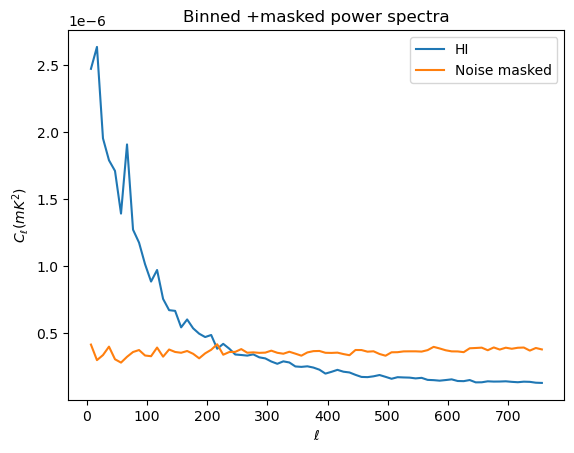

In [19]:
plt.plot(leff,hi_binned[:,0,0], label='HI')
# plt.plot(leff,fgds_binned[:,0,0], label='FGDS masked')
plt.plot(leff,noise_binned[:,0,0], label='Noise masked')
# plt.plot(leff,sky_binned[:,0,0], 'y--',label='Sky masked')
# plt.yscale('log')
plt.legend()
plt.xlabel('$\\ell$')
plt.ylabel('$C_{\\ell} (mK^2)$')
plt.title('Binned +masked power spectra')

## Make sure empirical covariance is PSD

In [20]:
c_hat=np.zeros((n_bins, nfreqs, nfreqs)) #clip any eigenvalues that are negative and put to zerp
for b in range(n_bins):
    
    cov = 0.5 * (sky_binned[b] + sky_binned[b].T) #symmetric or Hermitian?

    # Eigen-decomposition (since it's symmetric, use eigh)
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Zero out negative eigenvalues
    eigvals_clipped = np.clip(eigvals, a_min=0, a_max=None)
    
    epsilon=1e-12

    # Reconstruct the covariance matrix
    c_hat[b] = (eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T)#+ epsilon*np.identity(nfreqs) 

## Building the parametric HI model

In [21]:
bins=12

In [22]:
def build_trapezoidal_basis(freqs, bin, top_width=0.5):
    """
    Create trapezoidal basis functions (___/----\___) on frequency grid.
    
    Parameters:
    - freqs: 1D array of frequency bin centers (nf,)
    - n_bins: number of trapezoidal functions (i.e., nq)
    - top_width: fraction of bin width used for the flat top (0 < top_width < 1)

    Returns:
    - phi: shape (n_bins, nf), the basis matrix
    """
    nf = len(freqs)
    vmin, vmax = freqs[0], freqs[-1]
    bin_edges = np.linspace(vmin, vmax, bins + 1)
    bin_width = bin_edges[1] - bin_edges[0]
    flat_top = top_width * bin_width
    slope_width = (1 - top_width) * bin_width / 2  #slope= 1/slope_width

    phi = np.zeros((bin, nf))

    for i in range(bin):
        # Define edges of the trapezoid
        left = bin_edges[i] - slope_width
        start_flat = bin_edges[i]
        end_flat = bin_edges[i + 1]
        right = bin_edges[i + 1] + slope_width

        for j, v in enumerate(freqs):
            if left <= v < start_flat:
                phi[i, j] = (v - left) / slope_width
            elif start_flat <= v <= end_flat:
                phi[i, j] = 1.0
            elif end_flat < v <= right:
                phi[i, j] = (right - v) / slope_width
            else:
                phi[i, j] = 0.0

    return phi


<>:3: SyntaxWarning: invalid escape sequence '\_'
<>:3: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_1306602/3797101895.py:3: SyntaxWarning: invalid escape sequence '\_'
  Create trapezoidal basis functions (___/----\___) on frequency grid.


using the unbinned HI covariance so that later there isnt any problem when converting to maps for empirical covariance

In [23]:
from itertools import product
from numpy.linalg import lstsq

P, Q = 5,bins-1  #degree
v0=freqs[23]
n=0.5

# Step 1: Extract diagonal
hi=cl_hi[2:,:54,:54]
nell,*_ = hi.shape
C_diag = np.array([np.diag(hi[i]) for i in range(nell)])  # shape (nell, nf)

# Step 2: Log coordinates
log_l = np.log10(ells)  # shape (nell,)
log_v = np.log10(freqs[:-1])  # shape (nf,)
scaling = (freqs[:-1] / v0)**(-n)  # shape (nf,)

# Step 3: Build hat-shaped basis
phi = build_trapezoidal_basis(freqs[:-1], bins)  # shape (nq, nf)
# Unnormalized Psi: each row is φ_q(v) * scaling
Psi_unnorm = phi * scaling[None, :]  # shape (nq, nf)

# Normalize across q (rows) for each v (column)
Psi = Psi_unnorm / Psi_unnorm.sum(axis=0, keepdims=True)
print(Psi.shape)# shape (nq, nf)
# Psi = phi * scaling[None, :]              # shape (nq, nf)

# Step 4: Build coeff matrix
basis_terms = list(product(range(P + 1), range(Q + 1))) # all (p, q) pairs (0,0), (0,1), ..., (P,Q)
n_terms = len(basis_terms) # total number of basis functions (P + 1) * (Q + 1)

X = np.zeros((nell * nfreqs, n_terms))# rows = data points, cols = basis terms
y = C_diag.reshape(-1) #flatten target values to shape (nell * nf,)
print(y.shape)
print(len(ells)*nfreqs)

for i, (p, q) in enumerate(basis_terms):
    # Outer product: (nell,) x (nf,) → shape (nell, nf)
    X[:, i] = np.outer(log_l**p, Psi[q,:]).reshape(-1)

# Step 5: Solve least mean squares
a_vec, residuals, rank, s = lstsq(X, y, rcond=471256)
# a_vec=a_vec/np.linalg.norm(a_vec)
a_matrix = a_vec.reshape((P + 1, Q + 1))  # shape (P+1, Q+1)
print(a_matrix.shape)
print(a_vec.shape)

# Step 6: Reconstruct the fitted diagonal
C_fit_diag = np.zeros((nell, nfreqs))
for p in range(P + 1):
    for q in range(Q + 1):
        C_fit_diag +=a_matrix[p, q] * np.outer(log_l**p, Psi[q])

# Step 7: Expand to full (nell, nf, nf) with diagonal only
C_fit = np.zeros((nell, nfreqs, nfreqs))
for i in range(nell):
    np.fill_diagonal(C_fit[i], C_fit_diag[i])


(12, 54)
(41364,)
41364
(6, 12)
(72,)


SVD of coefficient matrix

In [24]:
U,D,Vt=np.linalg.svd(X, full_matrices=False)
# U.shape
X_test=U@ np.diag(D) @Vt
a_svd=Vt.T @ np.linalg.inv(np.diag(D)) @ U.T @ (X@a_vec)
a_svd

array([ 3.52096056e-06,  1.87880400e-06,  1.17603830e-06,  7.15709241e-07,
        4.52730212e-07,  2.95916908e-07,  1.95250297e-07,  1.34125871e-07,
        9.23700756e-08,  6.56963721e-08,  4.76324925e-08,  3.34171217e-08,
       -1.06016478e-05, -5.54201293e-06, -3.19999571e-06, -1.72030559e-06,
       -9.21322539e-07, -4.79967497e-07, -2.24801158e-07, -9.02022199e-08,
       -1.36560842e-08,  2.38481821e-08,  4.26305800e-08,  5.03540785e-08,
        1.87403174e-05,  9.00026637e-06,  5.01386379e-06,  2.55608040e-06,
        1.28455824e-06,  6.04542872e-07,  2.27203559e-07,  3.84995541e-08,
       -6.08397735e-08, -1.02859598e-07, -1.19093994e-07, -1.19037630e-07,
       -1.34911435e-05, -5.98002188e-06, -3.18376998e-06, -1.50182370e-06,
       -6.72138969e-07, -2.47186664e-07, -2.55984790e-08,  7.50624045e-08,
        1.19547740e-07,  1.30676741e-07,  1.28533883e-07,  1.16801897e-07,
        4.13520344e-06,  1.69667870e-06,  8.51893150e-07,  3.56721120e-07,
        1.25249675e-07,  

Convert toy model covariances to maps

In [25]:
model_map=[]
for i in range(nfreqs):
    model_map.append(hp.synfast(C_fit[:,i,i], nside))

model_map = np.array(model_map)


Construct empirical covariance in parameter space

In [26]:
chat_new=np.zeros_like(fgds_cl)
for i in range(nfreqs):
    chat_new[:,i,i] = hp.anafast(model_map[i]+ fgds[i]+ noise[i])
*_,chat_binned_new= bin_spectra(chat_new,nside, 10)
chat_binned_new.shape

(76, 54, 54)

Bin toy model

In [ ]:
C_fit_full = np.zeros((lmax+1, nfreqs, nfreqs))
C_fit_full[2:, :, :] = C_fit  # insert your toy model starting at l=2

leff, n_bins, C_fit_binned = bin_spectra(C_fit_full, nside, 10)

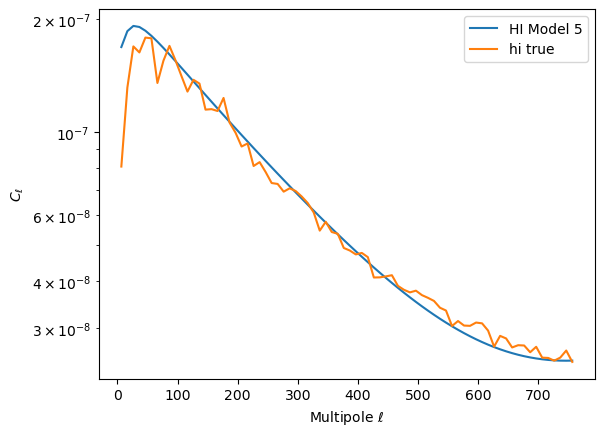

In [28]:
# plt.plot(leff,fgds_binned[:,26,26], label='Foregrounds ')
# plt.plot(leff,noise_binned[:,26,26], label='Noise   ')
# plt.plot(leff,chat_binned_new[:,26,26],'k.', label='Total Empirical')

# C_total= (hi_binned + fgds_binned + noise_binned)/np.linalg.norm(total)
# plt.plot(leff,C_total[:,20,20], label='total')

plt.plot(leff,C_fit_binned[:,26,26], label='HI Model 5')
plt.plot(leff,hi_binned[:,26,26],'-', label='hi true')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_{\ell}$')
plt.legend()

In [29]:
freqs[26]

np.int64(804)

Mean Squared Error Optimization

In [194]:
noise_diag=np.array([np.diag(noise_binned[i]) for i in range(n_bins)])
fgds_diag=np.array([np.diag(fgds_binned[i]) for i in range(n_bins)])

# Use the consistently-masked sky spectrum minus known components as the HI target.
# sky_binned, noise_binned, fgds_binned are all masked + fsky-corrected, so the
# subtraction is self-consistent and the residual is ~0 at the true coefficients.
hi_target = np.array([np.diag(hi_binned[i]) for i in range(n_bins)])  # shape (n_bins, nfreqs)
norm_hi = np.linalg.norm(hi_target)


Normalizing

In [195]:
nell=n_bins
log_ell = np.log10(leff)  # shape (nell,)   

In [196]:
def loss(a):
    a_mat = a.reshape((P + 1, Q + 1))
    C_model = np.zeros((nell, nfreqs))
    for p in range(P + 1):
        for q in range(Q + 1):
            C_model += a_mat[p, q] * np.outer(log_ell**p, Psi[q])
    r = ((C_model - hi_target) / norm_hi).reshape(-1)
    return 0.5 * np.dot(r, r)


def grad_loss(a):
    a_mat = a.reshape((P + 1, Q + 1))
    C_model = np.zeros((nell, nfreqs))
    for p in range(P + 1):
        for q in range(Q + 1):
            C_model += a_mat[p, q] * np.outer(log_ell**p, Psi[q])
    r = (C_model - hi_target) / norm_hi
    grad = np.zeros_like(a_mat)
    for p in range(P + 1):
        for q in range(Q + 1):
            basis = np.outer(log_ell**p, Psi[q])
            grad[p, q] = np.sum(r * basis) / norm_hi
    return grad.reshape(-1)


In [197]:
print(loss(a_vec))
print(np.linalg.norm(grad_loss(a_vec)))
print(np.max(np.abs(grad_loss(a_vec))))

0.015850315136678395
522065.0837498333
345713.9926115005


In [198]:
from scipy.optimize import check_grad
print(check_grad(loss, grad_loss, a_vec))

511318087.16756046


In [199]:
from scipy.optimize import minimize

res1 = minimize(loss,a_vec,
               jac=grad_loss,
               method='L-BFGS-B',
               options={'disp': True, 'maxls':10000, 'maxfun': 600000,'ftol': 1e-12,'gtol': 1e-7, 'maxiter': 15000}) #, 'maxls':100,'xtol': 1e-15, 'gtol': 1e-15, 'verbose': 2

a_opt1 = res1.x.reshape((P+1, Q+1))

/tmp/ipykernel_1306602/128997380.py:3: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res1 = minimize(loss,a_vec,


In [200]:
from pprint import pprint
pprint(res1)


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.015177403384534561
        x: [ 2.103e-06  1.748e-06 ...  9.289e-09  7.665e-09]
      nit: 6180
      jac: [-8.945e+00 -1.693e+01 ...  4.344e+01  6.001e+01]
     nfev: 6567
     njev: 6567
 hess_inv: <72x72 LbfgsInvHessProduct with dtype=float64>


In [201]:
print(np.linalg.norm(res1.jac))

151.53505838194062


In [280]:
f=36

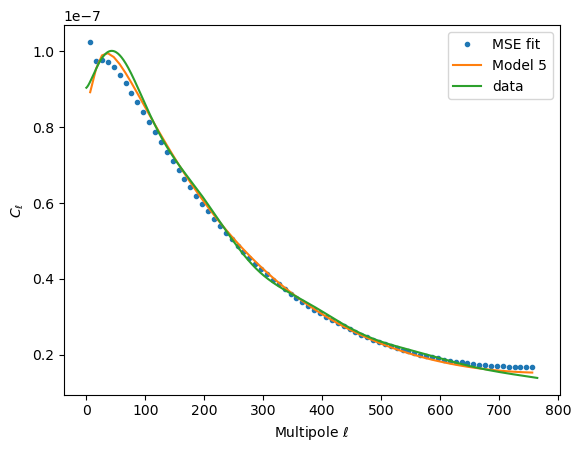

In [281]:
a_new = a_opt1.reshape((P+1, Q+1))
C_new = np.zeros((nell, nfreqs))
for p in range(P + 1):
    for q in range(Q + 1):
        C_new += (a_new[p, q]) * np.outer(log_ell**p, Psi[q])

C_mse = np.zeros((nell, nfreqs, nfreqs))
for i in range(nell):
    np.fill_diagonal(C_mse[i], C_new[i])

plt.plot( leff,C_mse[:,f,f], '.',label='MSE fit')
plt.plot( leff,C_fit_binned[:,f, f],label='Model 5')
plt.plot(cl_hi[2:,f,f],label='data')
# plt.plot(leff, fgds_binned[:,f, f],label='fgds masked')
plt.ylabel(r'$C_{\ell}$')
plt.xlabel(r'Multipole $\ell$')
# plt.yscale('log')
# plt.xscale('log')
plt.legend()

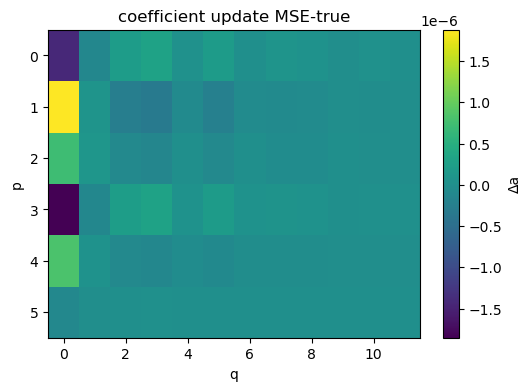

In [303]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.imshow(a_new - a_matrix, aspect='auto')
plt.colorbar(label='Δa')
plt.xlabel('q')
plt.ylabel('p')
plt.title('coefficient update MSE-true')
plt.show()

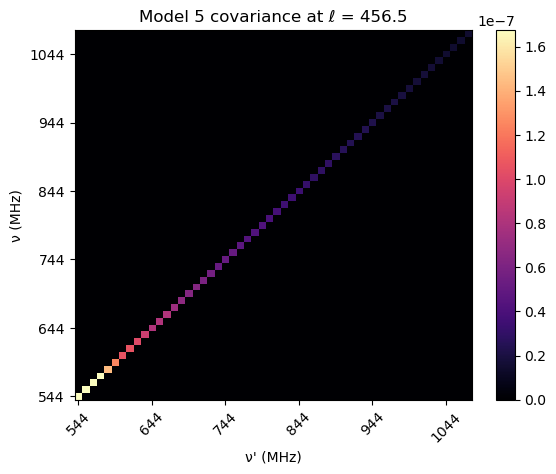

In [223]:
l=45
plt.imshow(C_fit_binned[l], origin='lower', cmap='magma', aspect='auto',)
plt.title(f"Model 5 covariance at ℓ = {leff[l]}")
plt.xlabel("ν' (MHz)")
plt.ylabel("ν (MHz)")
step = 10
xticks = np.arange(0, nfreqs - 1, step)
yticks = xticks

# Labels for spaced ticks
xtick_labels = [f"{freqs[i]}" for i in xticks]
ytick_labels = xtick_labels.copy()

plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45)
plt.yticks(ticks=yticks, labels=ytick_labels)
plt.colorbar()

In [161]:
leff[45]

np.float64(456.5)

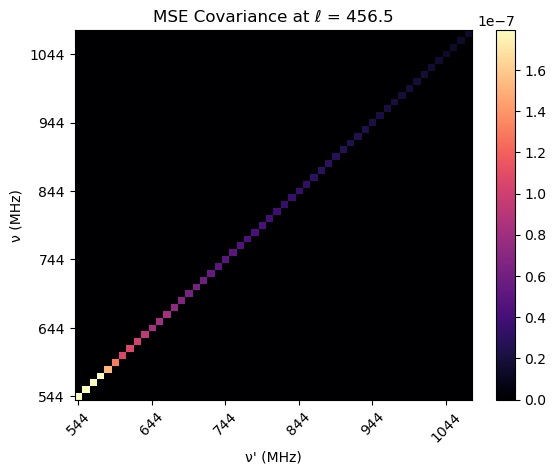

In [162]:
plt.imshow(C_mse[l], origin='lower', cmap='magma', aspect='auto')

plt.title(f"MSE Covariance at ℓ = {leff[l]}")
plt.xlabel("ν' (MHz)")
plt.ylabel("ν (MHz)")
step = 10
xticks = np.arange(0, nfreqs - 1, step)
yticks = xticks

# Labels for spaced ticks
xtick_labels = [f"{freqs[i]}" for i in xticks]
ytick_labels = xtick_labels.copy()

plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45)
plt.yticks(ticks=yticks, labels=ytick_labels)
plt.colorbar()

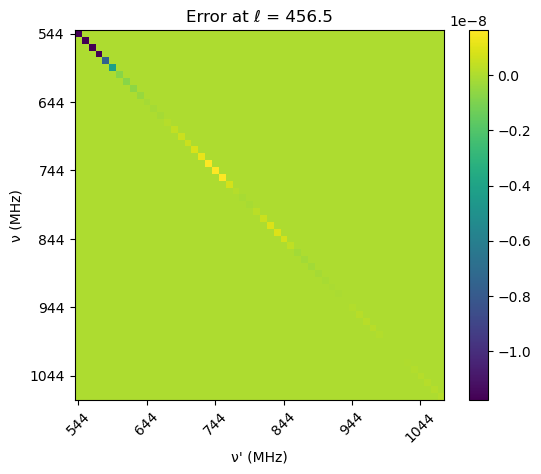

In [163]:
plt.imshow((C_fit_binned[l]-C_mse[l])) #/np.linalg.norm(C_fit_binned)
plt.title(f"Error at ℓ = {leff[l]}")
plt.xlabel("ν' (MHz)")
plt.ylabel("ν (MHz)")
step = 10
xticks = np.arange(0, nfreqs - 1, step)
yticks = xticks

# Labels for spaced ticks
xtick_labels = [f"{freqs[i]}" for i in xticks]
ytick_labels = xtick_labels.copy()

plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45)
plt.yticks(ticks=yticks, labels=ytick_labels)
plt.colorbar()

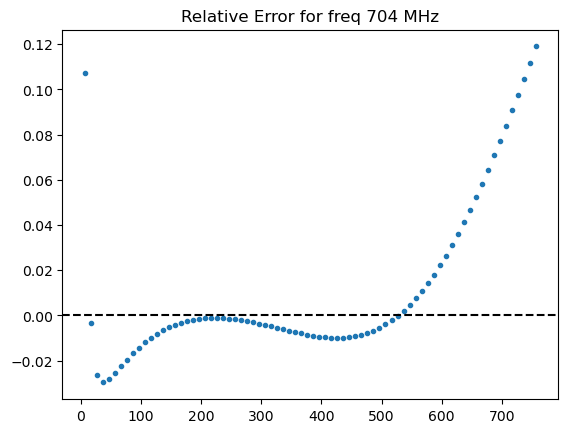

In [224]:
plt.plot(leff,(C_mse[:,f, f]- C_fit_binned[:,f,f])/C_fit_binned[:,f,f], '.',label='error')
plt.title(f"Relative Error for freq {freqs[f]} MHz")
plt.axhline(0, color='k', linestyle='--')

In [168]:
def is_psd(P, tol=0):
    eigenvalues = np.linalg.eigvalsh(P)  # symmetric-optimized
    return np.all(eigenvalues >= -tol) 
print("Is model PSD?", is_psd(chat_binned_new))

Is model PSD? True


SMICA Loss

In [283]:
from numpy.linalg import slogdet, inv

scale = np.linalg.norm(noise_binned + fgds_binned + C_fit_binned)

def build_C_model(a):
    a_mat = a.reshape((P + 1, Q + 1))
    log_C_diag = np.zeros((nell, nfreqs))
    for p in range(P + 1):
        for q in range(Q + 1):
            log_C_diag += a_mat[p, q] * np.outer(log_ell**p, Psi[q])
    # Clip before exp so the line search never produces inf/nan.
    # exp(30) ~ 1e13 mK^2 is already unphysical, so no valid minimum is outside this range.
    log_C_diag = np.clip(log_C_diag, -30, 30)
    C_diag = np.exp(log_C_diag)
    C_full = np.zeros((nell, nfreqs, nfreqs))
    for i in range(nell):
        np.fill_diagonal(C_full[i], C_diag[i])
    return C_full


def smica_loss(a):
    loss = 0.0
    C_model = build_C_model(a)
    for b in range(n_bins):
        C_emp = sky_binned[b] / scale
        C_tot = (C_model[b] + noise_binned[b] + fgds_binned[b]) / scale
        C_tot_inv = np.linalg.inv(C_tot)
        _, logdet = slogdet(C_emp @ C_tot_inv)
        trace_term = np.trace(C_emp @ C_tot_inv)
        loss += trace_term - logdet - nfreqs
    return loss


def jacobian(a):
    C_model = build_C_model(a)
    grad = np.zeros((P + 1, Q + 1))
    for b in range(n_bins):
        C_emp = sky_binned[b] / scale
        C_tot = (C_model[b] + noise_binned[b] + fgds_binned[b]) / scale
        C_tot_inv = np.linalg.inv(C_tot)
        Delta = C_tot_inv - C_tot_inv @ C_emp @ C_tot_inv
        C_diag_b = np.diag(C_model[b])
        for p in range(P + 1):
            for q in range(Q + 1):
                dR = np.zeros((nfreqs, nfreqs))
                np.fill_diagonal(dR, C_diag_b * (log_ell[b]**p) * Psi[q])
                grad[p, q] += np.trace(Delta @ dR) / scale
    return grad.reshape(-1)


In [284]:
smica_loss(res1.x)

np.float64(54188.77828844472)

In [285]:
def is_psd(P, tol=0):
    eigenvalues = np.linalg.eigvalsh(P)  # symmetric-optimized
    return np.all(eigenvalues >= -tol) 
print("Is model PSD?", is_psd(chat_binned_new))

Is model PSD? True


Using the result from MSE optimization in SMICA

In [261]:
from scipy.optimize import minimize

# Build initial guess in log-space: fit log(hi_target) with the polynomial basis
# evaluated at the binned ells, so build_C_model(a0_log) ≈ hi_target.
X_log = np.zeros((nell * nfreqs, n_terms))
for i, (p, q) in enumerate(basis_terms):
    X_log[:, i] = np.outer(log_ell**p, Psi[q]).reshape(-1)

log_hi = np.log(np.maximum(hi_target, 1e-30)).reshape(-1)
a0_log, *_ = np.linalg.lstsq(X_log, log_hi, rcond=None)

# Rescale so the optimizer sees O(1) parameters
a_scale = np.abs(a0_log).max()
x0_scaled = a0_log / a_scale

def smica_loss_scaled(a_hat):
    return smica_loss(a_hat * a_scale)

def jacobian_scaled(a_hat):
    return jacobian(a_hat * a_scale) * a_scale

res2 = minimize(smica_loss_scaled, x0_scaled,
               jac=jacobian_scaled,
               method='L-BFGS-B',
               options={'ftol': 1e-12, 'gtol': 1e-6, 'maxiter': 10000, 'maxls': 50})

res2_x = res2.x * a_scale
a_opt2 = res2_x.reshape((P+1, Q+1))
print(res2.message, '| nit:', res2.nit, '| fun:', res2.fun)


CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH | nit: 8 | fun: 217.3728396130179


In [262]:
from pprint import pprint

pprint(res2)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 217.3728396130179
        x: [-3.756e-01 -2.605e-01 ...  2.859e-03  5.614e-03]
      nit: 8
      jac: [ 1.386e+01 -2.709e+01 ...  2.705e+01  3.527e+01]
     nfev: 74
     njev: 74
 hess_inv: <72x72 LbfgsInvHessProduct with dtype=float64>


In [263]:
freqs[40]

np.int64(944)

In [305]:
# ── MSE error bars (linear model, Hessian of least-squares loss) ─────────────
# Hessian of 0.5*||(X_log @ a - hi_target)/norm_hi||^2 is X_log.T @ X_log / norm_hi^2
Sigma_mse = np.linalg.inv(X_log.T @ X_log) * norm_hi**2

sigma_mse = np.zeros((nell, nfreqs))
for b in range(nell):
    for v in range(nfreqs):
        J = np.array([log_ell[b]**p * Psi[q, v] for p, q in basis_terms])
        sigma_mse[b, v] = np.sqrt(J @ Sigma_mse @ J)

# ── SMICA error bars (log-space model, Fisher information) ───────────────────
# F[m,n] = sum_b 0.5 * tr(M^{-1} dR_m M^{-1} dR_n),  M = C_model + noise + fgds
# The scale factors in C_tot cancel, so this is in terms of unscaled quantities.
# dR_m = diag(C_diag * log_ell^p * Psi_q)  (chain rule through exp)
C_model_smica = build_C_model(res2_x)
F_smica = np.zeros((n_terms, n_terms))
for b in range(n_bins):
    M_inv = np.linalg.inv(C_model_smica[b] + noise_binned[b] + fgds_binned[b])
    C_diag_b = np.diag(C_model_smica[b])
    dRs = [np.diag(C_diag_b * (log_ell[b]**p) * Psi[q])
           for p, q in basis_terms]          # precompute all dR for this bin
    for m in range(n_terms):
        A = M_inv @ dRs[m] @ M_inv            # shared factor for row m
        for n_idx in range(m, n_terms):
            val = 0.5 * np.trace(A @ dRs[n_idx])
            F_smica[m, n_idx] += val
            if n_idx != m:
                F_smica[n_idx, m] += val

Sigma_smica = np.linalg.inv(F_smica)

# Propagate to C_ell via delta method: sigma_C = C * sqrt(Var(log C))
sigma_smica = np.zeros((nell, nfreqs))
for b in range(nell):
    for v in range(nfreqs):
        J = np.array([log_ell[b]**p * Psi[q, v] for p, q in basis_terms])
        sigma_smica[b, v] = C_model_smica[b, v, v] * np.sqrt(J @ Sigma_smica @ J)


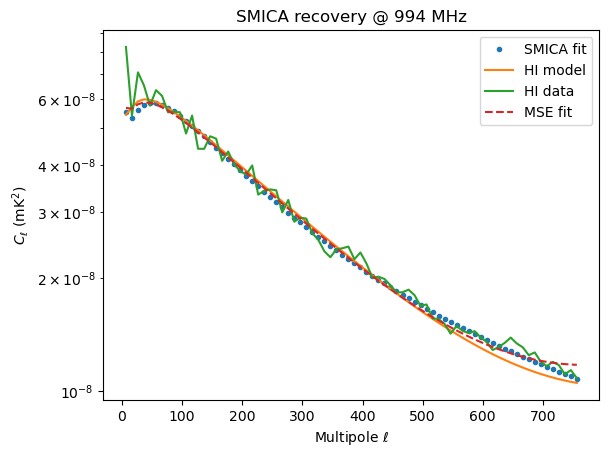

In [307]:
f = 45
# C_model_smica already computed in the error cell above
plt.plot(leff, C_model_smica[:, f, f], '.', label='SMICA fit')
plt.plot(leff, C_fit_binned[:, f, f], label='HI model')
plt.plot(leff, hi_binned[:, f, f], label='HI data')
plt.plot(leff, C_mse[:, f, f], '--', label='MSE fit')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$ (mK$^2$)')
plt.title(f'SMICA recovery @ {freqs[f]} MHz')
plt.yscale('log')
plt.legend()


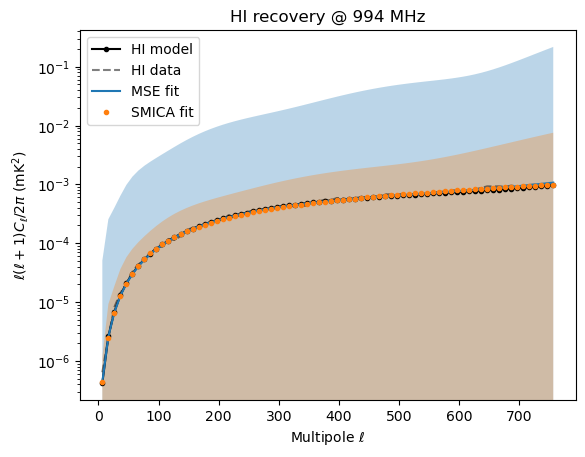

In [326]:
f = 45
factor = leff * (leff + 1) / (2 * np.pi)

C_mse_d   = factor * np.array([C_mse[b, f, f]          for b in range(nell)])
C_smica_d = factor * np.array([C_model_smica[b, f, f]  for b in range(nell)])
sigma_mse_f   = factor * sigma_mse[:, f]
sigma_smica_f = factor * sigma_smica[:, f]

fig, ax = plt.subplots()
ax.plot(leff, factor * np.array([C_fit_binned[b, f, f] for b in range(nell)]),
        'k.-', label='HI model')
ax.plot(leff, factor * np.array([hi_binned[b, f, f] for b in range(nell)]),
        'k--', alpha=0.5, label='HI data')

ax.plot(leff, C_mse_d, label='MSE fit')
ax.fill_between(leff, C_mse_d - sigma_mse_f, C_mse_d + sigma_mse_f, alpha=0.3)

ax.plot(leff, C_smica_d, '.',label='SMICA fit')
ax.fill_between(leff, C_smica_d - sigma_smica_f, C_smica_d + sigma_smica_f, alpha=0.3)

ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell / 2\pi$ (mK$^2$)')
ax.set_title(f'HI recovery @ {freqs[f]} MHz')
ax.set_yscale('log')
ax.legend()


Text(0.5, 0, 'Multipole $\\ell$')

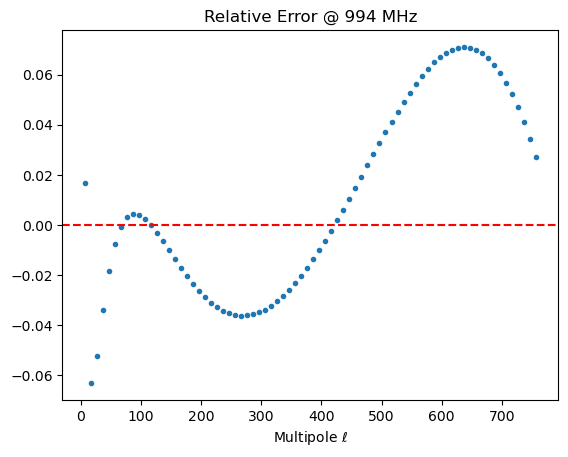

In [266]:
plt.plot(leff,(C_smica[:,f,f]-C_fit_binned[:,f,f])/C_fit_binned[:,f,f], '.',label='Error')
plt.axhline(0, color='r', linestyle='--')
plt.title(f'Relative Error @ {freqs[f]} MHz')
plt.xlabel(r'Multipole $\ell$')


In [267]:
freqs[0]

np.int64(544)

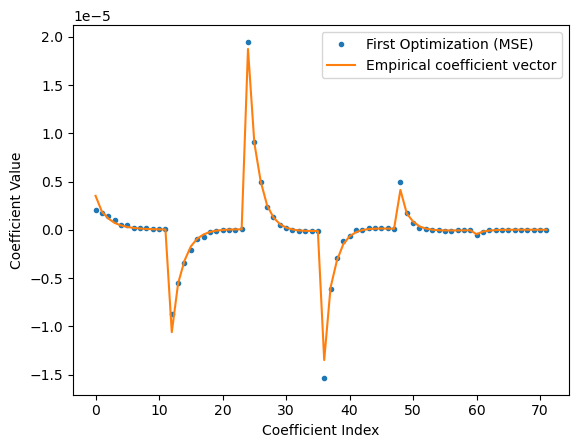

In [272]:
plt.plot(res1.x, '.',label='First Optimization (MSE)')
# plt.plot(res2.x, '-',label='Second Optimization (SMICA)')
plt.plot(a_vec,label='Empirical coefficient vector')
plt.ylabel('Coefficient Value')
plt.xlabel('Coefficient Index')
plt.legend()
# plt.ylim(4e-6, -4e-6)

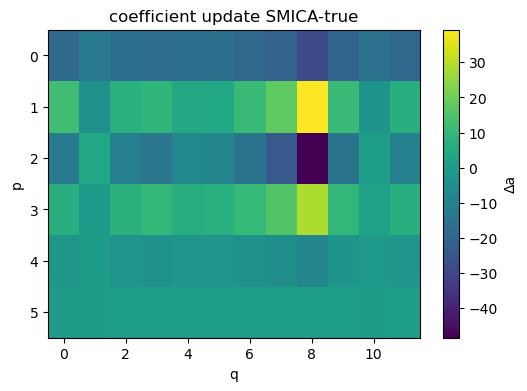

In [302]:
plt.figure(figsize=(6,4))
plt.imshow(a_opt2 - a_matrix, aspect='auto')
plt.colorbar(label='Δa')
plt.xlabel('q')
plt.ylabel('p')
plt.title('coefficient update SMICA-true')
plt.show()

EXTRAAAA

In [86]:
def fisher_information(cov_hi):
    """
    Compute Fisher Information Matrix for SMICA model.
    
    Parameters:
        a_vec: (n_coeffs,) flattened polynomial coefficients
        logl: (B,) log10(ell_bin_centers)
        Psi: (Q, nf) frequency basis functions
        R_fg: (B, nf, nf)
        R_noise: (B, nf, nf)
        n_b: (B,) number of modes per bin
        P: polynomial degree
    
    Returns:
        FIM: (n_coeffs, n_coeffs) Fisher Information Matrix
    """
    B, nfreqs = fgds_binned.shape[0], fgds_binned.shape[1]
    Q1 = Psi.shape[0]
    n_coeffs = (P + 1) * Q1

    # Build model + gradient of HI covariances
    # R_hi, grad_R_hi = model_cov_and_grad(a_k, logl, trapezoid, poly)  # Shapes: (B, nf, nf), (B, n_coeffs, nf, nf)
    R_Y =cov_hi + fgds_binned + noise_binned  # (B, nf, nf)
    # print(R_Y.shape, grad_R_hi.shape)
    dR= np.zeros((B, nfreqs,nfreqs, n_coeffs))  # (B, nf, nf, n_coeffs)
    

    FIM = np.zeros((n_coeffs, n_coeffs))

    for b in range(B):
        for p in range(P + 1):
            for q in range(Q1):
                idx = q * (P + 1) + p
                dR[b, :,:, idx] = np.diag(((log_ell[b] ** p) * Psi[q]))
        inv_R = np.linalg.inv(R_Y[b])  # (nf, nf)
        for m in range(n_coeffs):
            dRm = dR[b, :, :,m]  # (nf, nf)
            for n in range(m, n_coeffs):
                dRn = dR[b, :, :,n]  # (nf, nf)

                # Compute trace term: Tr( R⁻¹ dR_m R⁻¹ dR_n )
                term = inv_R @ dRm @ inv_R @ dRn
                trace_val = np.trace(term)
                FIM[m, n] += 0.5 *  trace_val #n_b[b] *

    # Symmetrize the matrix
    # FIM = FIM + FIM.T - np.diag(np.diag(FIM))
    return FIM


In [87]:
F=fisher_information(C_smica)

In [88]:
F_hat=fisher_information(C_fit_binned)

In [89]:
inv_fish= np.linalg.inv(F)
inv_fish_hat= np.linalg.inv(F_hat)

In [90]:
v_min= np.min(inv_fish_hat)
v_max= np.max(inv_fish_hat)

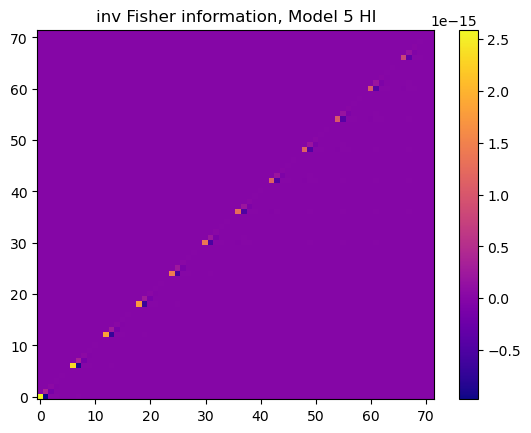

In [91]:
plt.imshow(inv_fish_hat, origin='lower', cmap='plasma', aspect='auto', vmin=v_min, vmax=v_max)
plt.colorbar()
plt.title(f"inv Fisher information, Model 5 HI")
plt.show()

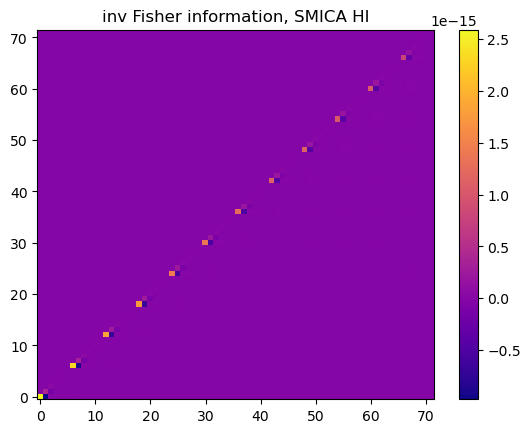

In [92]:
plt.imshow(inv_fish, origin='lower', cmap='plasma', aspect='auto', vmin=v_min, vmax=v_max)
plt.colorbar()
plt.title(f"inv Fisher information, SMICA HI")
plt.show()

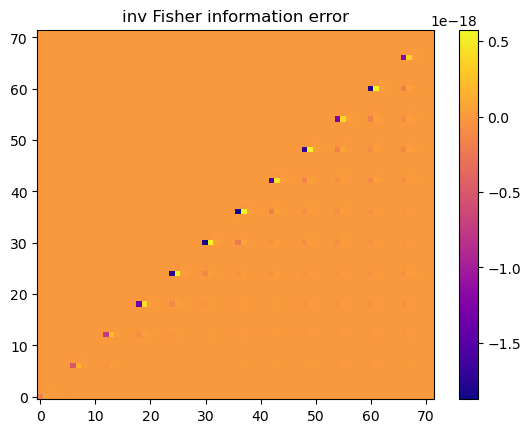

In [93]:
plt.imshow(inv_fish-inv_fish_hat, origin='lower', cmap='plasma', aspect='auto')
plt.colorbar()
plt.title(f"inv Fisher information error")
plt.show()

In [ ]:
# np.allclose(C_fit,build_C_model(a_vec))

In [ ]:
# np.min(np.linalg.eigvalsh(build_C_model(a_vec)))

Gradient Descent

In [ ]:
# a_current = 2* a_vec
# alpha = 1e-14
# tol_grad=1e-2

# for i in range(100000):
#     loss_current = smica_loss(a_current)
#     grad_current = jacobian(a_current)
#     grad_norm = np.linalg.norm(grad_current)
    
#     # if grad_norm > 1e3:  # clip gradient norm or scale step
#     #     grad_current = grad_current / grad_norm * 1e3
    
#     a_current = a_current - alpha * grad_current

#     if i % 1000 == 0:
#         print(f"Step {i}, loss = {loss_current:.6e}, grad norm = {grad_norm:.3e}")
#     if np.linalg.norm(grad_current) < tol_grad:
#         print(f"Stopping at iter {i}: gradient small.")
#         break



In [ ]:
# a_d= a_current.reshape((P+1, Q+1))
# C_d= np.zeros((nell, nf))
# for p in range(P + 1):
#     for q in range(Q + 1):
#         C_d += (a_d[p, q]) * np.outer(log_l**p, Psi[q])



# plt.plot( C_d[:,26], '.',label='Fitted')
# plt.plot( C_fit_diag[:,26], label='model')
# plt.legend()